In [468]:
import numpy as np
import pandas as pd
import random
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

In [469]:
df=pd.read_csv("/content/crop_disease_environment_large_dataset_3000.csv")
df.head()
# data explantions

,crop,soil_type,soil_ph,temperature,humidity,rainfall,disease
0,Pepper,Clay,6.7,35,91,148,Bacterial Leaf Spot
1,Pepper,Sandy,5.5,26,89,46,Bacterial Spot
2,Tomato,Loamy,6.5,28,82,10,Early Blight
3,Tomato,Loamy,6.0,21,78,15,Early Blight
4,Tomato,Sandy,5.8,33,69,172,Healthy


In [470]:
df.tail()

,crop,soil_type,soil_ph,temperature,humidity,rainfall,disease
2995,Potato,Clay,7.0,34,64,19,Healthy
2996,Potato,Clay,5.7,30,58,53,Healthy
2997,Pepper,Sandy,6.1,27,95,168,Bacterial Leaf Spot
2998,Potato,Clay,6.4,31,94,81,Early Blight
2999,Tomato,Clay,6.1,21,87,105,Late Blight


In [471]:
# input of crop taken
unique_crops = df['crop'].unique()
unique_crops

array(['Pepper', 'Tomato', 'Potato'], dtype=object)

In [472]:
# finding the types disease
disease=df['disease'].unique()
disease

array(['Bacterial Leaf Spot', 'Bacterial Spot', 'Early Blight', 'Healthy',
       'Late Blight'], dtype=object)

In [473]:
df.shape

(3000, 7)

In [474]:
#data cleaning and pre-processing
df.isnull().sum()

,0
crop,0
soil_type,0
soil_ph,0
temperature,0
humidity,0
rainfall,0
disease,0


In [475]:
# find dupilactes
df.duplicated().sum()

np.int64(0)

In [476]:
df.describe()

,soil_ph,temperature,humidity,rainfall
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,6.359700,26.537333,75.429333,94.369333
std,0.495635,5.129917,11.815140,48.916451
min,5.500000,18.000000,55.000000,10.000000
25%,5.900000,22.000000,65.000000,51.000000
50%,6.400000,27.000000,76.000000,96.000000
75%,6.800000,31.000000,86.000000,137.000000
max,7.200000,35.000000,95.000000,180.000000


In [477]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   crop         3000 non-null   object 
 1   soil_type    3000 non-null   object 
 2   soil_ph      3000 non-null   float64
 3   temperature  3000 non-null   int64  
 4   humidity     3000 non-null   int64  
 5   rainfall     3000 non-null   int64  
 6   disease      3000 non-null   object 
dtypes: float64(1), int64(3), object(3)
memory usage: 164.2+ KB


In [478]:
# Separate numerical data
numerical_df = df.select_dtypes(include=['int64', 'float64'])
print("Numerical Data (first 5 rows):")
display(numerical_df.head())

Numerical Data (first 5 rows):


,soil_ph,temperature,humidity,rainfall
0,6.7,35,91,148
1,5.5,26,89,46
2,6.5,28,82,10
3,6.0,21,78,15
4,5.8,33,69,172


In [479]:
# Separate categorical data
categorical_df = df.select_dtypes(include=['object', 'category'])
print("Categorical Data (first 5 rows):")
display(categorical_df.head())

Categorical Data (first 5 rows):


,crop,soil_type,disease
0,Pepper,Clay,Bacterial Leaf Spot
1,Pepper,Sandy,Bacterial Spot
2,Tomato,Loamy,Early Blight
3,Tomato,Loamy,Early Blight
4,Tomato,Sandy,Healthy


In [480]:
#Target Variable Analysis
# count the varibles
df['temperature'].value_counts().head()
df['humidity'].value_counts().head()
df['soil_ph'].value_counts().head()
df['rainfall'].value_counts().head()

,count
temperature,
32,196
25,183
19,178
26,175
24,174


,count
humidity,
85,94
94,90
71,88
88,88
63,84


,count
soil_ph,
6.1,204
7.1,194
6.9,189
5.8,187
6.4,185


,count
rainfall,
35,31
64,28
103,27
48,26
142,26


<Figure size 1200x700 with 0 Axes>

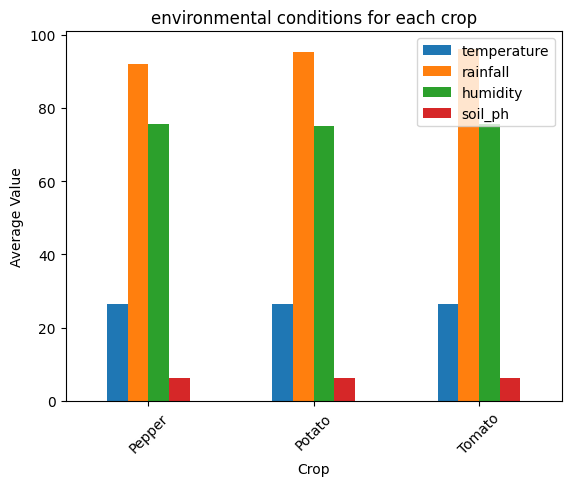

In [481]:
#Exploratory Data Analysis

# Columns to use
plt.figure(figsize=(12,7))
num_cols = ['temperature', 'rainfall', 'humidity', 'soil_ph']
# Group by crop and calculate mean
grouped = df.groupby('crop')[num_cols].mean()
# Plot grouped bar chart
grouped.plot(kind='bar')
plt.xlabel('Crop')
plt.ylabel('Average Value')
plt.title('environmental conditions for each crop')
plt.xticks(rotation=45)
plt.show();


<Figure size 1200x700 with 0 Axes>

<Axes: xlabel='soil_type', ylabel='count'>

Text(0.5, 1.0, 'Disease Counts by Soil Type')

Text(0.5, 0, 'Soil Type')

Text(0, 0.5, 'Count')

([0, 1, 2], [Text(0, 0, 'Clay'), Text(1, 0, 'Sandy'), Text(2, 0, 'Loamy')])

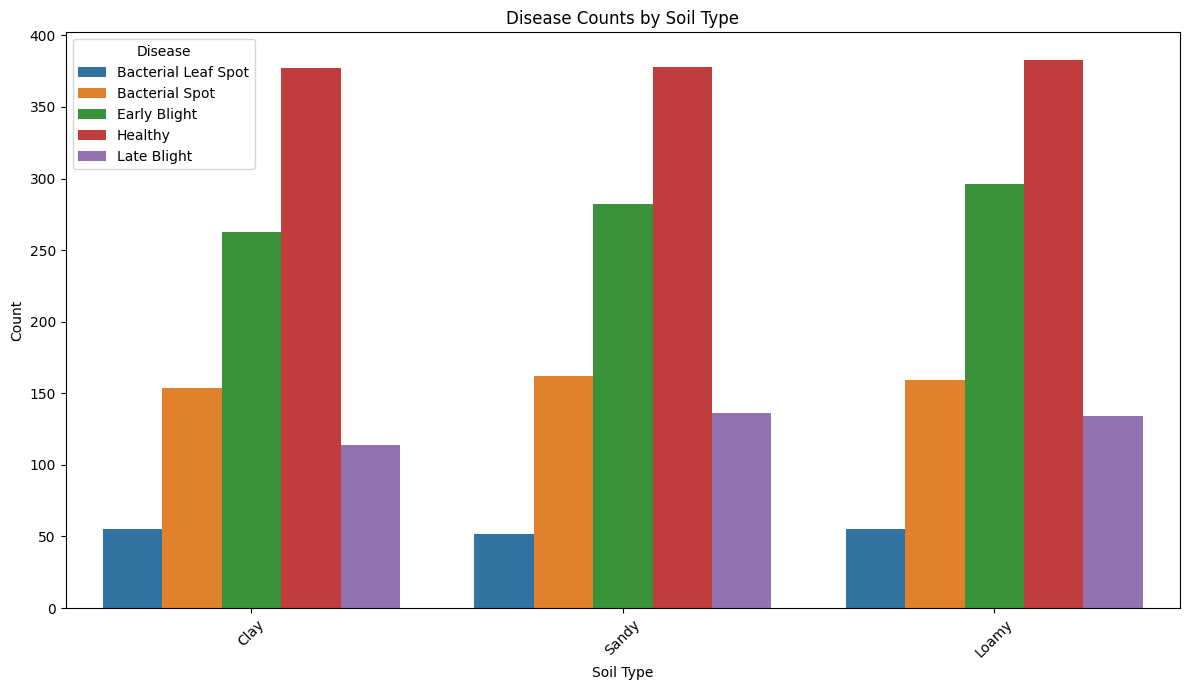

In [482]:
# Grouped bar chart for Soil Type vs Disease counts
plt.figure(figsize=(12, 7))
sns.countplot(data=df, x='soil_type', hue='disease', palette='tab10')
plt.title('Disease Counts by Soil Type')
plt.xlabel('Soil Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Disease')
plt.tight_layout()
plt.show()

,proportion
disease,
Healthy,0.379333
Early Blight,0.280333
Bacterial Spot,0.158333
Late Blight,0.128000
Bacterial Leaf Spot,0.054000


<Figure size 640x480 with 0 Axes>

<Axes: xlabel='disease', ylabel='count'>

Text(0.5, 1.0, 'Distribution of Disease Status')

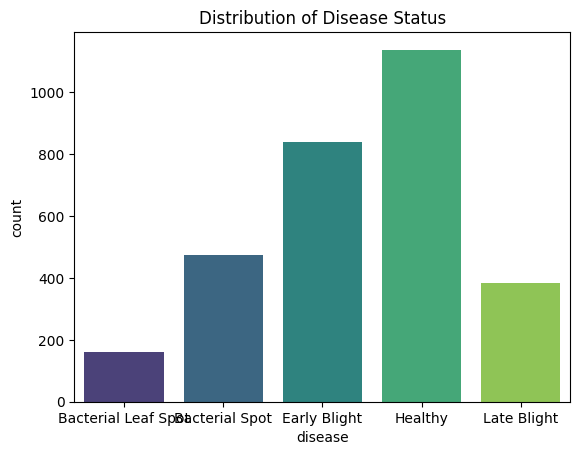

In [483]:
# Value counts of target variable
df['disease'].value_counts(10,6)
# Plot distribution
plt.figure()
sns.countplot(x='disease', data=df, hue='disease', palette='viridis', legend=False) # Updated to address FutureWarning
plt.title("Distribution of Disease Status")
plt.show()


array([[<Axes: title={'center': 'soil_ph'}>,
        <Axes: title={'center': 'temperature'}>],
       [<Axes: title={'center': 'humidity'}>,
        <Axes: title={'center': 'rainfall'}>]], dtype=object)

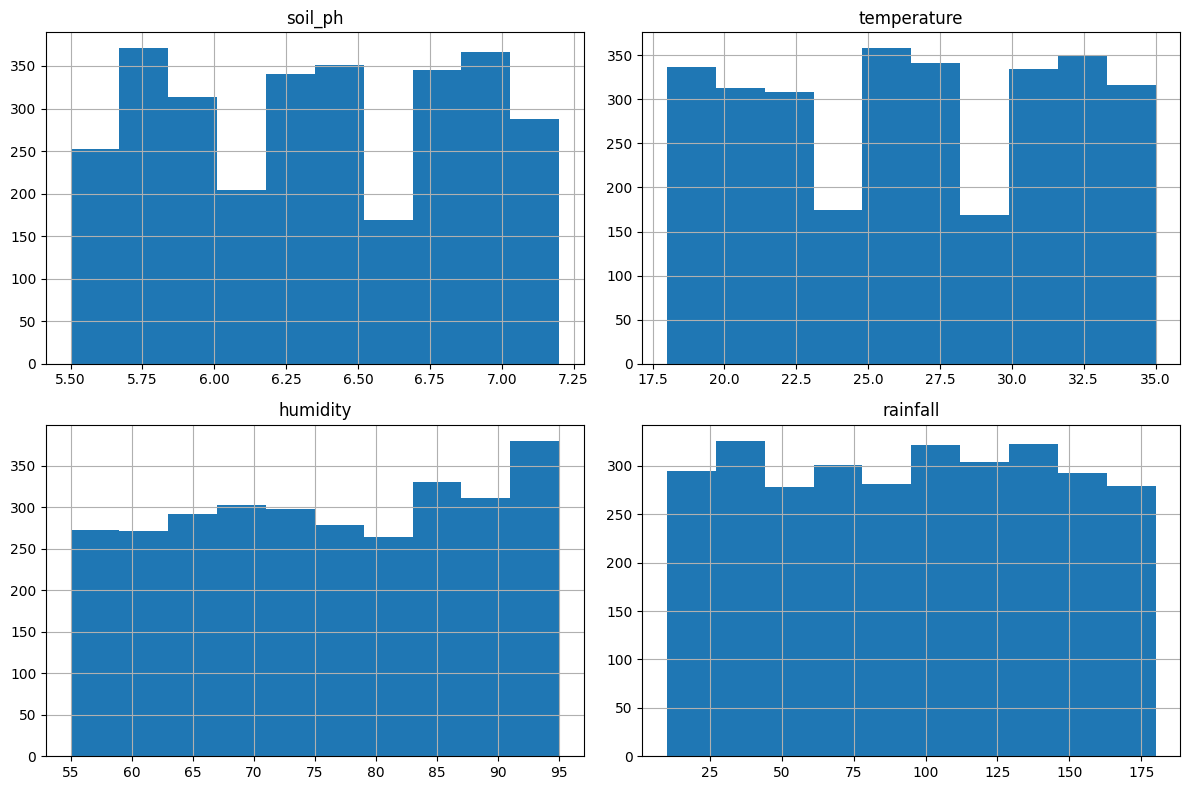

In [484]:
numerical_cols = df.select_dtypes(include=np.number).columns
df[numerical_cols].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Feature Correlation Heatmap')

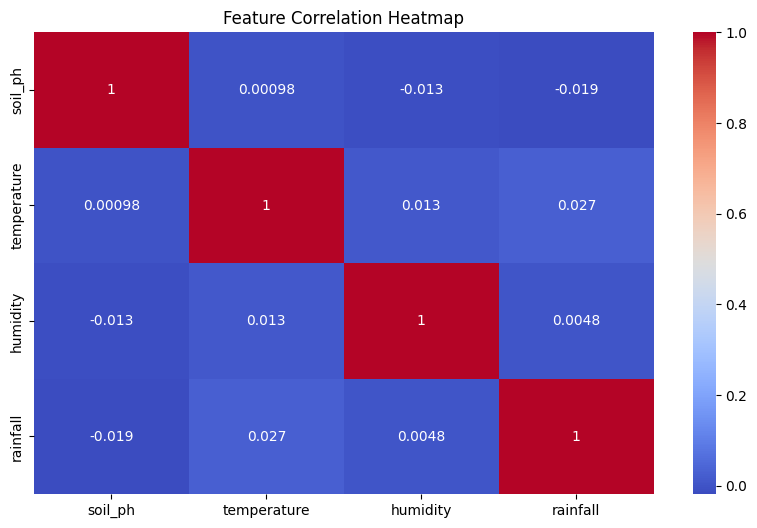

In [485]:
#Corelation Analysis
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


<Figure size 640x480 with 0 Axes>

<Axes: xlabel='disease', ylabel='soil_ph'>

Text(0.5, 1.0, 'soil_ph vs Disease Status')

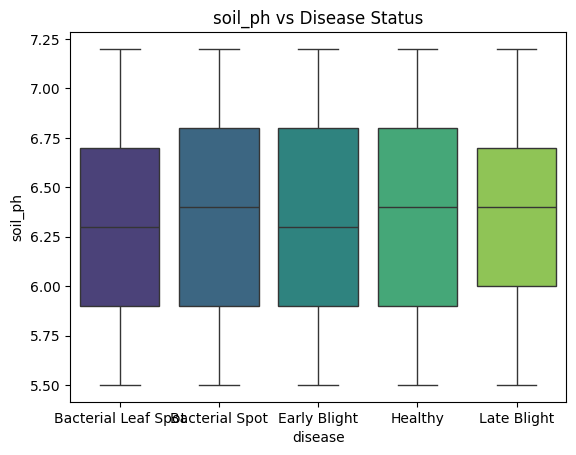

<Figure size 640x480 with 0 Axes>

<Axes: xlabel='disease', ylabel='temperature'>

Text(0.5, 1.0, 'temperature vs Disease Status')

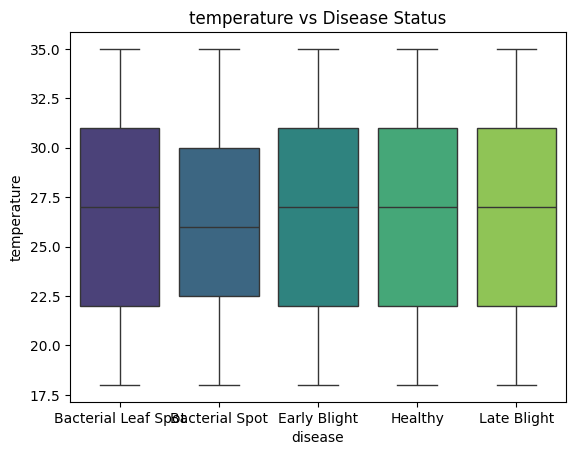

<Figure size 640x480 with 0 Axes>

<Axes: xlabel='disease', ylabel='humidity'>

Text(0.5, 1.0, 'humidity vs Disease Status')

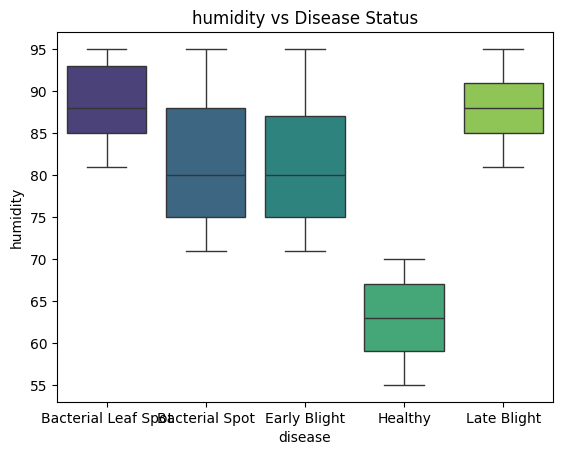

<Figure size 640x480 with 0 Axes>

<Axes: xlabel='disease', ylabel='rainfall'>

Text(0.5, 1.0, 'rainfall vs Disease Status')

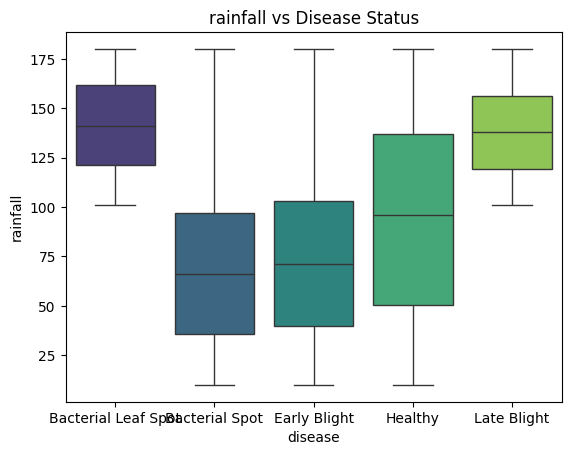

In [486]:
# Feature vs Target Analysis
for col in numerical_cols:
    if col != 'disease':
        plt.figure()
        sns.boxplot(x='disease', y=col, data=df, hue='disease', palette='viridis', legend=False)
        plt.title(f"{col} vs Disease Status")
        plt.show()

In [487]:
#speraction x and # according to my data set y([x=futerus],[y=target])
x=df.drop('disease',axis=1)
y=df['disease']
x

,crop,soil_type,soil_ph,temperature,humidity,rainfall
0,Pepper,Clay,6.7,35,91,148
1,Pepper,Sandy,5.5,26,89,46
2,Tomato,Loamy,6.5,28,82,10
3,Tomato,Loamy,6.0,21,78,15
4,Tomato,Sandy,5.8,33,69,172
...,...,...,...,...,...,...
2995,Potato,Clay,7.0,34,64,19
2996,Potato,Clay,5.7,30,58,53
2997,Pepper,Sandy,6.1,27,95,168
2998,Potato,Clay,6.4,31,94,81


In [488]:
y

,disease
0,Bacterial Leaf Spot
1,Bacterial Spot
2,Early Blight
3,Early Blight
4,Healthy
...,...
2995,Healthy
2996,Healthy
2997,Bacterial Leaf Spot
2998,Early Blight


In [489]:
#ENCODING
# converted data categorical data to numerical data
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
X = df.drop("disease", axis=1)# drop the target values
X_encoded = pd.get_dummies(X, columns=["crop", "soil_type"])
print(X_encoded.head().astype(int))

   soil_ph  temperature  humidity  rainfall  crop_Pepper  crop_Potato  \
0        6           35        91       148            1            0   
1        5           26        89        46            1            0   
2        6           28        82        10            0            0   
3        6           21        78        15            0            0   
4        5           33        69       172            0            0   

   crop_Tomato  soil_type_Clay  soil_type_Loamy  soil_type_Sandy  
0            0               1                0                0  
1            0               0                0                1  
2            1               0                1                0  
3            1               0                1                0  
4            1               0                0                1  


In [490]:
# encoding the target variabels(label encoding)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder() # create line an instance of thr labelencoder class.
y = df["disease"]
y_encoded = le.fit_transform(y)# converting the  catericoal---- to--- numerical
print(y_encoded[:10])

[0 1 2 2 3 2 3 4 4 0]


In [491]:
# trainang and testing the data
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_encoded,y_encoded,test_size=0.2,random_state=42)

In [492]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((2400, 10), (600, 10), (2400,), (600,))

In [493]:
# FuterScaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)# train the data for modelbulding
X_test = scaler.transform(x_test)# test data only in transfromed


#model building

Decisiontree classifier

In [494]:
from sklearn.tree import DecisionTreeClassifier

In [495]:
# 1. Re-instantiate and train DecisionTreeClassifier
model_dt = DecisionTreeClassifier(random_state=42)
model_dt


DecisionTreeClassifier(random_state=42)

In [496]:
model_dt.fit(x_train, y_train)


DecisionTreeClassifier(random_state=42)

In [497]:
# make predction
y_pred = model_dt.predict(x_test)
y_pred


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


array([4, 4, 0, 0, 0, 4, 4, 0, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 0, 0,
       4, 0, 4, 0, 4, 4, 0, 4, 0, 4, 4, 0, 4, 4, 0, 4, 4, 4, 4, 0, 0, 4,
       0, 0, 4, 4, 0, 4, 4, 4, 4, 4, 4, 0, 0, 0, 4, 4, 0, 4, 4, 4, 0, 4,
       0, 0, 0, 4, 0, 0, 4, 0, 0, 4, 4, 4, 4, 0, 4, 4, 4, 0, 4, 4, 4, 0,
       0, 4, 4, 0, 4, 0, 4, 4, 0, 4, 4, 4, 0, 0, 4, 4, 0, 0, 0, 0, 0, 4,
       4, 4, 4, 4, 4, 0, 0, 4, 4, 4, 4, 0, 0, 4, 0, 0, 0, 4, 4, 0, 4, 4,
       4, 0, 4, 4, 0, 4, 4, 4, 4, 4, 0, 4, 0, 0, 0, 4, 4, 0, 0, 0, 0, 4,
       4, 0, 4, 4, 4, 0, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,
       0, 0, 4, 4, 4, 0, 4, 4, 4, 4, 0, 4, 0, 4, 4, 4, 4, 0, 4, 4, 4, 4,
       4, 0, 4, 4, 0, 4, 4, 0, 4, 4, 4, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4, 4,
       4, 0, 4, 4, 0, 0, 0, 0, 4, 4, 4, 0, 4, 4, 4, 0, 0, 0, 0, 4, 4, 0,
       4, 0, 4, 0, 4, 0, 4, 4, 0, 4, 4, 0, 4, 4, 4, 4, 4, 0, 4, 4, 4, 4,
       4, 4, 0, 4, 4, 4, 4, 4, 4, 0, 4, 4, 0, 4, 0, 4, 0, 4, 4, 4, 4, 0,
       0, 0, 0, 0, 4, 4, 0, 4, 4, 0, 0, 0, 4, 4, 0,

In [498]:
#shiw the accurecy
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.16166666666666665

In [499]:
#This helps understand why accuracy is low
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.11      1.00      0.20        23
           1       0.00      0.00      0.00        88
           2       0.00      0.00      0.00       172
           3       0.00      0.00      0.00       243
           4       0.19      1.00      0.32        74

    accuracy                           0.16       600
   macro avg       0.06      0.40      0.10       600
weighted avg       0.03      0.16      0.05       600



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [500]:
#Improve Decision Tree (Hyperparameter Tuning)


In [501]:
from sklearn.model_selection import GridSearchCV

In [502]:
param_grid = {
    'max_depth': [3, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

In [503]:
#Apply Grid Search
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 10, 20],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [504]:
# best parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [505]:
#Train Best Model
best_dt = grid_search.best_estimator_

y_pred_best = best_dt.predict(X_test)

print("Improved Accuracy:", accuracy_score(y_test, y_pred_best))

Improved Accuracy: 0.995


Random Forest Model

In [506]:
from sklearn.ensemble import RandomForestClassifier


In [507]:
rf = RandomForestClassifier(random_state=42)
rf

RandomForestClassifier(random_state=42)

In [508]:
rf.fit(x_train, y_train)
rf

RandomForestClassifier(random_state=42)

RandomForestClassifier(random_state=42)

In [509]:
y_pred_rf = rf.predict(X_test)
y_pred_rf

array([2, 3, 1, 0, 1, 3, 3, 1, 4, 2, 1, 3, 4, 3, 4, 3, 3, 3, 2, 3, 3, 3,
       2, 1, 4, 1, 3, 3, 1, 3, 1, 3, 2, 3, 2, 4, 3, 3, 3, 3, 2, 3, 3, 2,
       1, 3, 3, 3, 3, 2, 2, 4, 4, 2, 3, 1, 1, 3, 2, 2, 1, 3, 3, 2, 1, 4,
       3, 1, 1, 2, 3, 3, 3, 3, 1, 2, 3, 3, 3, 1, 2, 3, 2, 0, 4, 3, 2, 3,
       1, 2, 2, 1, 4, 3, 4, 2, 3, 2, 3, 2, 1, 3, 2, 2, 0, 3, 0, 3, 3, 3,
       3, 3, 2, 2, 2, 3, 0, 2, 3, 4, 3, 1, 3, 2, 1, 3, 3, 4, 3, 3, 2, 2,
       2, 3, 2, 2, 0, 2, 3, 3, 3, 3, 0, 3, 3, 1, 3, 4, 2, 3, 3, 3, 3, 2,
       3, 1, 2, 2, 3, 1, 2, 3, 2, 4, 0, 2, 2, 3, 3, 2, 4, 2, 3, 3, 3, 2,
       1, 3, 2, 2, 3, 1, 3, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2,
       3, 1, 3, 2, 1, 2, 2, 3, 2, 2, 2, 3, 4, 2, 2, 3, 3, 2, 4, 2, 2, 2,
       2, 3, 2, 3, 1, 3, 1, 3, 3, 2, 2, 1, 3, 2, 4, 0, 0, 1, 1, 3, 4, 3,
       3, 1, 3, 3, 3, 0, 2, 2, 0, 2, 2, 1, 2, 3, 2, 3, 3, 1, 2, 2, 4, 3,
       4, 2, 3, 3, 3, 2, 3, 2, 4, 3, 2, 4, 3, 2, 1, 4, 0, 3, 4, 4, 2, 1,
       3, 3, 3, 1, 2, 4, 1, 3, 2, 3, 1, 1, 3, 2, 3,

In [510]:
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.9933333333333333


Logistic regression

In [511]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression


In [512]:
lr = LogisticRegression(max_iter=1000)
lr

LogisticRegression(max_iter=1000)

In [513]:
lr.fit(x_train, y_train)
lr

LogisticRegression(max_iter=1000)

LogisticRegression(max_iter=1000)

In [514]:
y_pred_lr = lr.predict(X_test)
y_pred_lr

array([2, 3, 1, 0, 1, 3, 3, 0, 4, 2, 1, 3, 2, 3, 2, 3, 3, 3, 2, 3, 3, 3,
       2, 1, 2, 1, 3, 3, 1, 3, 1, 3, 2, 3, 2, 4, 3, 3, 3, 3, 2, 3, 3, 2,
       1, 3, 3, 3, 3, 2, 2, 4, 4, 2, 2, 1, 1, 3, 2, 2, 1, 3, 3, 2, 1, 4,
       3, 1, 1, 2, 3, 3, 3, 3, 1, 2, 3, 3, 3, 1, 2, 3, 2, 0, 2, 3, 2, 3,
       1, 2, 2, 1, 4, 3, 4, 2, 3, 4, 3, 2, 1, 3, 2, 2, 0, 3, 0, 3, 3, 3,
       3, 3, 2, 2, 2, 3, 0, 4, 3, 4, 3, 1, 3, 2, 1, 3, 3, 4, 3, 3, 2, 2,
       2, 3, 2, 2, 1, 2, 3, 3, 3, 3, 0, 3, 3, 1, 3, 2, 2, 3, 3, 3, 3, 2,
       3, 1, 2, 2, 3, 1, 2, 3, 2, 4, 0, 2, 2, 3, 3, 2, 4, 4, 3, 3, 3, 2,
       1, 3, 2, 2, 3, 1, 3, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2,
       3, 1, 3, 2, 1, 2, 4, 3, 2, 2, 2, 3, 4, 2, 2, 3, 3, 2, 2, 2, 2, 2,
       2, 3, 2, 3, 1, 3, 1, 3, 3, 2, 2, 1, 3, 2, 4, 1, 0, 1, 1, 3, 4, 3,
       3, 1, 3, 3, 3, 0, 2, 2, 1, 2, 2, 1, 2, 3, 2, 3, 3, 1, 2, 2, 4, 3,
       4, 2, 3, 3, 3, 2, 3, 2, 2, 3, 2, 4, 3, 2, 1, 4, 0, 3, 4, 2, 2, 0,
       3, 3, 3, 1, 2, 4, 1, 3, 2, 3, 1, 0, 3, 2, 3,

In [515]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9333333333333333


XGBoost


In [516]:
from xgboost import XGBClassifier


In [517]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')


In [518]:
xgb.fit(x_train, y_train)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [10:21:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [519]:
y_pred_xgb = xgb.predict(X_test)
y_pred_xgb

array([2, 3, 1, 0, 1, 3, 3, 1, 4, 2, 1, 3, 4, 3, 4, 3, 3, 3, 2, 3, 3, 3,
       2, 1, 4, 1, 3, 3, 1, 3, 1, 3, 2, 3, 2, 4, 3, 3, 3, 3, 2, 3, 3, 2,
       1, 3, 3, 3, 3, 2, 2, 4, 4, 2, 3, 1, 1, 3, 2, 2, 1, 3, 3, 2, 1, 4,
       3, 1, 1, 2, 3, 3, 3, 3, 1, 2, 3, 3, 3, 1, 2, 3, 2, 0, 4, 3, 2, 3,
       1, 2, 2, 1, 4, 3, 4, 2, 3, 2, 3, 2, 1, 3, 2, 2, 0, 3, 0, 3, 3, 3,
       3, 3, 2, 2, 2, 3, 0, 2, 3, 4, 3, 1, 3, 2, 1, 3, 3, 4, 3, 3, 2, 2,
       2, 3, 2, 2, 0, 2, 3, 3, 3, 3, 0, 3, 3, 1, 3, 4, 2, 3, 3, 3, 3, 2,
       3, 1, 2, 2, 3, 1, 2, 3, 2, 4, 0, 2, 2, 3, 3, 2, 4, 2, 3, 3, 3, 2,
       1, 3, 2, 2, 3, 1, 3, 3, 2, 3, 3, 2, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2,
       3, 1, 3, 2, 1, 2, 2, 3, 2, 2, 2, 3, 4, 2, 2, 3, 3, 2, 4, 2, 2, 2,
       2, 3, 2, 3, 1, 3, 1, 3, 3, 2, 2, 1, 3, 2, 4, 0, 0, 1, 1, 3, 4, 3,
       3, 1, 3, 3, 3, 0, 2, 2, 0, 2, 2, 1, 2, 3, 2, 3, 3, 1, 2, 2, 4, 3,
       4, 2, 3, 3, 3, 2, 3, 2, 4, 3, 2, 4, 3, 2, 1, 4, 0, 3, 4, 4, 2, 1,
       3, 3, 3, 1, 2, 4, 1, 3, 2, 3, 1, 1, 3, 2, 3,

In [520]:
print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Accuracy: 0.995


In [521]:
 #Best model pick

In [522]:
print("Decision Tree:", accuracy_score(y_test, y_pred))
print("Tuned Decision Tree:", accuracy_score(y_test, y_pred_best))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

Decision Tree: 0.16166666666666665
Tuned Decision Tree: 0.995
Random Forest: 0.9933333333333333
Logistic Regression: 0.9333333333333333
XGBoost: 0.995


In [523]:
from sklearn.metrics import classification_report

print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_lr))
print("XGBoost Report:\n", classification_report(y_test, y_pred_xgb))
print("Decision Tree Report:\n", classification_report(y_test, y_pred))

Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      0.96      0.98        23
           1       0.99      1.00      0.99        88
           2       0.98      1.00      0.99       172
           3       1.00      1.00      1.00       243
           4       1.00      0.96      0.98        74

    accuracy                           0.99       600
   macro avg       0.99      0.98      0.99       600
weighted avg       0.99      0.99      0.99       600

Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.73      0.83      0.78        23
           1       0.95      0.91      0.93        88
           2       0.90      0.94      0.92       172
           3       1.00      1.00      1.00       243
           4       0.85      0.77      0.81        74

    accuracy                           0.93       600
   macro avg       0.89      0.89      0.89       600
weighted avg       0.93  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# XGB BOOST
XGBoost was selected as the best model because it achieved the highest accuracy and F1-score compared to other models. It effectively handles complex and non-linear relationships in the data. The model also performs well on imbalanced datasets by balancing precision and recall. Compared to Decision Tree and Logistic Regression, it provides more reliable and consistent predictions. Therefore, XGBoost is the most suitable model for crop disease prediction.

In [467]:
import pickle
from google.colab import files

# Save the FITTED best model (XGBoost Classifier)
with open("xgb_best_model.pkl", "wb") as file:
    pickle.dump(xgb, file)   # or use best_model if selected automatically

print("Model 'xgb_best_model.pkl' saved successfully.")

# Download the saved model file
files.download("xgb_best_model.pkl")

Model 'xgb_best_model.pkl' saved successfully.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>